# Data merge and feature extraction
### The original dataset consisted of a time series of non-georeferenced data, including weather features averaged across the state of California and a single label indicating whether a fire had started on a given day.
### Our objective was to enhance this dataset by georeferencing both the fire labels and the weather features.

### Import libraries/data

In [ ]:
%reset -f
from __future__ import print_function

import math
import numpy as np
import numpy.linalg as nla
import pandas as pd
import re
import six
from os.path import join
import glob
import os
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
!pip install -q -U keras-tuner
from keras_tuner import HyperParameters

# feel free to import other libraries as needed
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Geo reference
import geopandas as gpd
from shapely.geometry import Point, MultiPoint


# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

from google.colab import files

# Improve pandas dataframe table display
pd.set_option('display.max_columns', None)

In [ ]:
# Access google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the USA counties shapefile
counties = gpd.read_file("zip:///content/drive/MyDrive/DATASCI207/Final Project/data/tl_2024_us_county.zip") #From: https://www2.census.gov/geo/tiger/TIGER2024/COUNTY/tl_2024_us_county.zip
counties = counties.to_crs("EPSG:4326")  # Convert to WGS 84 if necessary

In [ ]:
# Load the CONUS Climate divisions shapefile
conus_divisions = gpd.read_file("https://www.ncei.noaa.gov/pub/data/cirs/climdiv/CONUS_CLIMATE_DIVISIONS.shp.zip")
conus_divisions = conus_divisions.to_crs("EPSG:4326")  # Convert to WGS 84 if necessary

## Historical Cal Fire datasets merge

In [ ]:
# Load the original dataset
# From: https://zenodo.org/records/14712845/files/CA_Weather_Fire_Dataset_1984-2025.csv?download=1
fire_df = pd.read_csv("/content/drive/MyDrive/DATASCI207/Final Project/data/CA_Weather_Fire_Dataset_1984-2025.csv")

In [ ]:
# Explore the data file
print('Shape of data', fire_df.shape)
display(fire_df.head())

Shape of data (14988, 14)


,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
0,1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700,1
1,1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145,2
2,1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220,3
3,1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090,4
4,1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100,5


In [ ]:
# 1. How many columns are there in the dataset?
print("The dataset contains: ", len(fire_df.columns), " columns")
# 2. How many rows are there in the dataset?
print("The dataset contains: ", len(fire_df), " rows")
# 3. What are the column names?
print("The column names are: ", fire_df.columns)
# 4. List the number of unique values for each column in the data;
print("The number of unique values for each column are:\n", fire_df.nunique())
# 5. List the amount of FIRE_START_DAY;
print("The amount of FIRE_START_DAY in the column are:\n", fire_df.FIRE_START_DAY.sum())
# 6. Firs and last dates on the dataset;
print(f"The First date in the dataset is: {fire_df.DATE.min()} and the last date is: {fire_df.DATE.max()}")

The dataset contains:  14  columns
The dataset contains:  14988  rows
The column names are:  Index(['DATE', 'PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED',
       'FIRE_START_DAY', 'YEAR', 'TEMP_RANGE', 'WIND_TEMP_RATIO', 'MONTH',
       'SEASON', 'LAGGED_PRECIPITATION', 'LAGGED_AVG_WIND_SPEED',
       'DAY_OF_YEAR'],
      dtype='object')
The number of unique values for each column are:
 DATE                     14988
PRECIPITATION              184
MAX_TEMP                    57
MIN_TEMP                    44
AVG_WIND_SPEED              89
FIRE_START_DAY               2
YEAR                        42
TEMP_RANGE                  39
WIND_TEMP_RATIO           1660
MONTH                       12
SEASON                       4
LAGGED_PRECIPITATION       994
LAGGED_AVG_WIND_SPEED     1533
DAY_OF_YEAR                366
dtype: int64
The amount of FIRE_START_DAY in the column are:
 4971
The First date in the dataset is: 1984-01-01 and the last date is: 2025-01-12


In [ ]:
# Check for null values
display(fire_df.isnull().sum())

# Imputate missing values with Forward fill, we are trying to keep the time series integrity intact by filling instead of removing rows
fire_df.fillna(method='ffill', inplace=True)
display(fire_df.isnull().sum())

,0
DATE,0
PRECIPITATION,1
MAX_TEMP,1
MIN_TEMP,1
AVG_WIND_SPEED,12
FIRE_START_DAY,0
YEAR,0
TEMP_RANGE,1
WIND_TEMP_RATIO,12
MONTH,0


,0
DATE,0
PRECIPITATION,0
MAX_TEMP,0
MIN_TEMP,0
AVG_WIND_SPEED,0
FIRE_START_DAY,0
YEAR,0
TEMP_RANGE,0
WIND_TEMP_RATIO,0
MONTH,0


In [ ]:
# Cal Fire Historical fire perimeters https://www.fire.ca.gov/what-we-do/fire-resource-assessment-program/fire-perimeters
# From: https://gis.data.ca.gov/datasets/CALFIRE-Forestry::california-historical-fire-perimeters/explore?layer=0
geojson_path = "/content/drive/MyDrive/DATASCI207/Final Project/data/California_Fire_Perimeters_(all).geojson"  # Change this if necessary
gdf = gpd.read_file(geojson_path)

In [ ]:
# Explore the dataframe
display(gdf.head())

,OBJECTID,YEAR_,STATE,AGENCY,UNIT_ID,FIRE_NAME,INC_NUM,ALARM_DATE,CONT_DATE,CAUSE,C_METHOD,OBJECTIVE,GIS_ACRES,COMMENTS,COMPLEX_NAME,IRWINID,FIRE_NUM,COMPLEX_ID,DECADES,Shape__Area,Shape__Length,geometry
0,1,2023.0,CA,CDF,SKU,WHITWORTH,00004808,2023-06-17 00:00:00+00:00,2023-06-17 00:00:00+00:00,5.0,1.0,1.0,5.729125,None,None,{7985848C-0AC2-4BA4-8F0E-29F778652E61},None,None,2020.0,41407.839844,1247.166034,"POLYGON ((-122.91148 41.53201, -122.9115 41.53..."
1,2,2023.0,CA,LRA,BTU,KAISER,00010225,2023-06-02 00:00:00+00:00,2023-06-02 00:00:00+00:00,5.0,1.0,1.0,13.602380,None,None,{43EBCC88-B3AC-48EB-8EF5-417FE0939CCF},None,None,2020.0,93455.878906,1285.514550,"POLYGON ((-121.96182 39.8297, -121.96181 39.82..."
2,3,2023.0,CA,CDF,AEU,JACKSON,00017640,2023-07-01 00:00:00+00:00,2023-07-02 00:00:00+00:00,2.0,1.0,1.0,27.814460,None,None,{B64E1355-BF1D-441A-95D0-BC1FBB93483B},None,None,2020.0,183028.500000,2697.587429,"POLYGON ((-120.90644 38.29537, -120.90397 38.2..."
3,4,2023.0,CA,CDF,AEU,CARBON,00018821,2023-07-11 00:00:00+00:00,2023-07-11 00:00:00+00:00,9.0,1.0,1.0,58.760230,None,None,{CB41DB0A-E4B1-489D-A4EA-738F2CD6DB3B},None,None,2020.0,388221.953125,2548.738779,"POLYGON ((-120.98579 38.44344, -120.98488 38.4..."
4,5,2023.0,CA,CDF,AEU,LIBERTY,00018876,2023-07-11 00:00:00+00:00,2023-07-12 00:00:00+00:00,14.0,1.0,1.0,70.979000,None,None,{F83F70A4-07A7-40B8-BD51-10CCC1C30D63},None,None,2020.0,466456.007812,5106.936526,"POLYGON ((-120.98886 38.25035, -120.98895 38.2..."


In [ ]:
#Create a GeoDataFrame using the geometry column:
gdf = gpd.GeoDataFrame(gdf, geometry='geometry')

# Convert polygons to their centroid points
gdf['centroid'] = gdf.geometry.centroid

# Extract longitude (X) and latitude (Y)
gdf['longitude'] = gdf['centroid'].x
gdf['latitude'] = gdf['centroid'].y


# Perform spatial join to get county information
gdf = gpd.sjoin(gdf, counties, how="left", predicate="within", lsuffix="gdf", rsuffix="county")

# Perform spatial join to get CONUS climte divisions information with suffix to avoid 'index_right' conflict
gdf = gpd.sjoin(gdf, conus_divisions, how="left", predicate="within", lsuffix="gdf", rsuffix="conus")

# Show results including county and CONUS climate divisions info
display(gdf[["latitude", "longitude", "NAME_gdf", "NAME_conus", "CLIMDIV", 'CONT_DATE']].head())

,latitude,longitude,NAME_gdf,NAME_conus,CLIMDIV,CONT_DATE
0,41.532175,-122.912100,Siskiyou,NORTH COAST DRAINAGE,401.0,2023-06-17 00:00:00+00:00
1,39.830743,-121.962853,Butte,SACRAMENTO DRNG.,402.0,2023-06-02 00:00:00+00:00
2,38.295102,-120.904706,Amador,SAN JOAQUIN DRNG.,405.0,2023-07-02 00:00:00+00:00
3,38.441969,-120.984186,Amador,SAN JOAQUIN DRNG.,405.0,2023-07-11 00:00:00+00:00
4,38.247227,-120.995943,Amador,SAN JOAQUIN DRNG.,405.0,2023-07-12 00:00:00+00:00


In [ ]:
# Print the resultin columns
display(gdf.columns)

Index(['OBJECTID_gdf', 'YEAR_', 'STATE_gdf', 'AGENCY', 'UNIT_ID', 'FIRE_NAME',
       'INC_NUM', 'ALARM_DATE', 'CONT_DATE', 'CAUSE', 'C_METHOD', 'OBJECTIVE',
       'GIS_ACRES', 'COMMENTS', 'COMPLEX_NAME', 'IRWINID', 'FIRE_NUM',
       'COMPLEX_ID', 'DECADES', 'Shape__Area', 'Shape__Length', 'geometry',
       'centroid', 'longitude', 'latitude', 'index_county', 'STATEFP',
       'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME_gdf', 'NAMELSAD',
       'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT',
       'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'index_conus',
       'OBJECTID_conus', 'STATE_conus', 'STATE_FIPS', 'CD_2DIG', 'STATE_CODE',
       'CLIMDIV', 'CD_NEW', 'FIPS_CD', 'NCDC_GEO_I', 'NAME_conus', 'ST_ABBRV',
       'SHAPE_AREA', 'SHAPE_LEN'],
      dtype='object')

In [ ]:
# Convert the geo dataframe to pandas and drop the unused columns
df_from_gdf = pd.DataFrame(gdf.drop(columns=['OBJECTID_gdf', 'YEAR_', 'STATE_gdf', 'AGENCY', 'UNIT_ID', 'FIRE_NAME',
       'C_METHOD', 'OBJECTIVE', 'COMMENTS', 'COMPLEX_NAME', 'IRWINID', 'FIRE_NUM',
       'COMPLEX_ID', 'DECADES', 'Shape__Area', 'Shape__Length', 'geometry',
       'centroid', 'index_county', 'STATEFP',
       'COUNTYFP', 'COUNTYNS', 'GEOIDFQ', 'GEOID', 'NAMELSAD',
       'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'index_conus',
       'OBJECTID_conus', 'STATE_conus', 'STATE_FIPS', 'CD_2DIG', 'STATE_CODE',
       'CD_NEW', 'FIPS_CD', 'NCDC_GEO_I', 'ST_ABBRV',
       'SHAPE_AREA', 'SHAPE_LEN']))

# Convert 'CONT_DATE' to datetime objects
df_from_gdf['CONTAINMENT'] = pd.to_datetime(df_from_gdf['CONT_DATE'])
df_from_gdf.drop(columns=['CONT_DATE'], inplace=True)

# Convert 'ALARM_DATE' to datetime objects
df_from_gdf['DATETIME'] = pd.to_datetime(df_from_gdf['ALARM_DATE'])
df_from_gdf.drop(columns=['ALARM_DATE'], inplace=True)

# Calculate fire duration
df_from_gdf['DURATION'] = (df_from_gdf['CONTAINMENT'] - df_from_gdf['DATETIME']).dt.days
df_from_gdf.drop(columns=['CONTAINMENT'], inplace=True)

# Rename NAME_gdf column to county
df_from_gdf.rename(columns={'NAME_gdf': 'county'}, inplace=True)

# Rename NAME_conus column to conus_name
df_from_gdf.rename(columns={'NAME_conus': 'conus_name'}, inplace=True)

# Rename CLIMDIV column to conus_code
df_from_gdf.rename(columns={'CLIMDIV': 'conus_code'}, inplace=True)

# Rename GIS_ACRES column to county
df_from_gdf.rename(columns={'GIS_ACRES': 'ACRES'}, inplace=True)

print(f"Shape of df_from_gdf dataframe including empty datetimes:", df_from_gdf.shape)

# Drop rows where 'DATETIME' is NaN
df_from_gdf.dropna(subset=['DATETIME'], inplace=True)

print(f"Shape of df_from_gdf dataframe after removing empty datetimes:", df_from_gdf.shape)

# Extract date
df_from_gdf['DATE'] = df_from_gdf['DATETIME'].dt.date
df_from_gdf.drop(columns=['DATETIME'], inplace=True)

# Create a new column with count of occurrences for each date
df_from_gdf['fire_occurrences'] = df_from_gdf['DATE'].map(df_from_gdf['DATE'].value_counts())

# Keep only the first occurrence of each date
# df_from_gdf.drop_duplicates(subset=['DATE'], keep='first', inplace=True) (We decided to keep duplicated dates in the dataset to increase the number of samples)

# Print the shape of the resulting dataset
print(f"Shape of df_from_gdf dataframe after removing duplicated dates:", df_from_gdf.shape)

# Replace NaNs in the 'CAUSE' column with 0
df_from_gdf['CAUSE'].fillna(0, inplace=True)

# Replace NaNs in 'county' with 'Unknown'
df_from_gdf['county'].fillna('Unknown', inplace=True)

# Replace NaNs in 'INC_NUM' with 'Unknown'
df_from_gdf['INC_NUM'].fillna('Unknown', inplace=True)

# Filter the DataFrame according to dates
start_date = pd.to_datetime("1984-01-01").date()
end_date = pd.to_datetime("2025-01-12").date()
df_from_gdf = df_from_gdf[(df_from_gdf['DATE'] >= start_date) & (df_from_gdf['DATE'] <= end_date)]

# Reset index
df_from_gdf.reset_index(drop=True, inplace=True)

# Explore the resulting dataset
print(f"Resulting dataset shape: {df_from_gdf.shape}")
display(df_from_gdf.head())

Shape of df_from_gdf dataframe including empty datetimes: (22261, 10)
Shape of df_from_gdf dataframe after removing empty datetimes: (16865, 10)
Shape of df_from_gdf dataframe after removing duplicated dates: (16865, 11)
Resulting dataset shape: (10618, 11)


,INC_NUM,CAUSE,ACRES,longitude,latitude,county,conus_code,conus_name,DURATION,DATE,fire_occurrences
0,00004808,5.0,5.729125,-122.912100,41.532175,Siskiyou,401.0,NORTH COAST DRAINAGE,0.0,2023-06-17,3
1,00010225,5.0,13.602380,-121.962853,39.830743,Butte,402.0,SACRAMENTO DRNG.,0.0,2023-06-02,1
2,00017640,2.0,27.814460,-120.904706,38.295102,Amador,405.0,SAN JOAQUIN DRNG.,1.0,2023-07-01,1
3,00018821,9.0,58.760230,-120.984186,38.441969,Amador,405.0,SAN JOAQUIN DRNG.,0.0,2023-07-11,5
4,00018876,14.0,70.979000,-120.995943,38.247227,Amador,405.0,SAN JOAQUIN DRNG.,1.0,2023-07-11,5


In [ ]:
# Cal Fire Historical fire perimeters 2024/2025 https://lab.data.ca.gov/dataset/ca-perimeters-cal-fire-nifc-firis-public-view
# From: https://gis.data.cnra.ca.gov/api/download/v1/items/025fb2ea05f14890b2b11573341b5b18/geojson?layers=0
geojson_path2 = "/content/drive/MyDrive/DATASCI207/Final Project/data/CA_Perimeters_CAL_FIRE_NIFC_FIRIS_public_view.geojson"  # Change this if necessary
gdf2 = gpd.read_file(geojson_path2)

In [ ]:
# Convert polygons to their centroid points
gdf2['centroid'] = gdf2.geometry.centroid

# Extract longitude (X) and latitude (Y)
gdf2['longitude'] = gdf2['centroid'].x
gdf2['latitude'] = gdf2['centroid'].y

# Perform spatial join to get county information
gdf2 = gpd.sjoin(gdf2, counties, how="left", predicate="within", lsuffix="gdf", rsuffix="county")

# Perform spatial join to get CONUS climate divisions information with suffix to avoid 'index_right' conflict
gdf2 = gpd.sjoin(gdf2, conus_divisions, how="left", predicate="within", lsuffix="gdf", rsuffix="conus")

# Show results, including county and CONUS climate division info
display(gdf2[["latitude", "longitude", "NAME_gdf", "NAME_conus", "CLIMDIV"]].head())

,latitude,longitude,NAME_gdf,NAME_conus,CLIMDIV
0,35.514809,-117.652658,Kern,SOUTHEAST DESERT BASIN,407.0
1,34.882426,-120.244427,Santa Barbara,SOUTH COAST DRNG.,406.0
2,32.597442,-116.830121,San Diego,SOUTH COAST DRNG.,406.0
3,34.057977,-118.547618,Los Angeles,SOUTH COAST DRNG.,406.0
4,34.058878,-118.546911,Los Angeles,SOUTH COAST DRNG.,406.0


In [ ]:
display(gdf2.columns)

Index(['OBJECTID_gdf', 'GlobalID', 'type', 'source', 'poly_DateCurrent',
       'mission', 'incident_name', 'incident_number', 'area_acres',
       'description', 'FireDiscoveryDate', 'CreationDate', 'EditDate',
       'displayStatus', 'geometry', 'centroid', 'longitude', 'latitude',
       'index_county', 'STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ',
       'NAME_gdf', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP',
       'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON',
       'index_conus', 'OBJECTID_conus', 'STATE', 'STATE_FIPS', 'CD_2DIG',
       'STATE_CODE', 'CLIMDIV', 'CD_NEW', 'FIPS_CD', 'NCDC_GEO_I',
       'NAME_conus', 'ST_ABBRV', 'SHAPE_AREA', 'SHAPE_LEN'],
      dtype='object')

In [ ]:
# Convert the geo dataframe to pandas and drop the unused columns
df_from_gdf_2024 = pd.DataFrame(gdf2.drop(columns=['OBJECTID_gdf', 'GlobalID', 'type', 'source', 'poly_DateCurrent', 'mission',
       'incident_name', 'description',
       'CreationDate', 'EditDate', 'displayStatus',
       'geometry', 'centroid', 'index_county',
       'STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID',
       'GEOIDFQ', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'INTPTLAT', 'INTPTLON',
       'NAMELSAD', 'LSAD', 'ALAND', 'AWATER', 'index_conus', 'OBJECTID_conus', 'STATE', 'STATE_FIPS',
       'CD_2DIG', 'STATE_CODE', 'CD_NEW', 'FIPS_CD', 'NCDC_GEO_I',
       'ST_ABBRV', 'SHAPE_AREA', 'SHAPE_LEN']))

# Rename NAME_gdf column to county
df_from_gdf_2024.rename(columns={'NAME_gdf': 'county'}, inplace=True)

# Rename NAME_conus column to conus_name
df_from_gdf_2024.rename(columns={'NAME_conus': 'conus_name'}, inplace=True)

# Rename CLIMDIV column to conus_code
df_from_gdf_2024.rename(columns={'CLIMDIV': 'conus_code'}, inplace=True)

# Rename area_acres column to ACRES
df_from_gdf_2024.rename(columns={'area_acres': 'ACRES'}, inplace=True)

# Rename indident_name to INC_NUM
df_from_gdf_2024.rename(columns={'incident_number': 'INC_NUM'}, inplace=True)

# Convert 'FireDiscoveryDate' to datetime objects
df_from_gdf_2024['DATETIME'] = pd.to_datetime(df_from_gdf_2024['FireDiscoveryDate'])
df_from_gdf_2024.drop(columns=['FireDiscoveryDate'], inplace=True)

# Add 'CAUSE' column filled with 0
df_from_gdf_2024['CAUSE'] = 0

# Add 'DURATION' column filled with 0
df_from_gdf_2024['DURATION'] = 0

print(f"Shape of df_from_gdf_2024 dataframe including empty datetimes:", df_from_gdf_2024.shape)

# Drop rows where 'DATETIME' is NaN
df_from_gdf_2024.dropna(subset=['DATETIME'], inplace=True)

print(f"Shape of df_from_gdf dataframe after removing empty datetimes:", df_from_gdf_2024.shape)

# Extract date
df_from_gdf_2024['DATE'] = df_from_gdf_2024['DATETIME'].dt.date
df_from_gdf_2024.drop(columns=['DATETIME'], inplace=True)

# Create a new column with count of occurrences for each date
df_from_gdf_2024['fire_occurrences'] = df_from_gdf['DATE'].map(df_from_gdf['DATE'].value_counts())

# Keep only the first occurrence of each date
# df_from_gdf_2024.drop_duplicates(subset=['DATE'], keep='first', inplace=True)

print(f"Shape of df_from_gdf dataframe after removing duplicated dates:", df_from_gdf_2024.shape)

# Replace NaNs in the 'CAUSE' column with 0
df_from_gdf_2024['CAUSE'].fillna(0, inplace=True)

# Replace NaNs in 'county' with 'Unknown'
df_from_gdf_2024['county'].fillna('Unknown', inplace=True)

# Replace NaNs in 'INC_NUM' with 'Unknown'
df_from_gdf_2024['INC_NUM'].fillna('Unknown', inplace=True)

# Filter the DataFrame according to dates
start_date = pd.to_datetime("1984-01-01").date()
end_date = pd.to_datetime("2025-01-12").date()
df_from_gdf_2024 = df_from_gdf_2024[(df_from_gdf_2024['DATE'] >= start_date) & (df_from_gdf_2024['DATE'] <= end_date)]

# Reset index
df_from_gdf_2024.reset_index(drop=True, inplace=True)

# Explore the resulting dataset
print(f"Resulting dataset shape: {df_from_gdf_2024.shape}")
display(df_from_gdf_2024.head())


Shape of df_from_gdf_2024 dataframe including empty datetimes: (1260, 10)
Shape of df_from_gdf dataframe after removing empty datetimes: (158, 10)
Shape of df_from_gdf dataframe after removing duplicated dates: (158, 11)
Resulting dataset shape: (156, 11)


,INC_NUM,ACRES,longitude,latitude,county,conus_code,conus_name,CAUSE,DURATION,DATE,fire_occurrences
0,2024-CACDD-019350,1.200000,-117.652658,35.514809,Kern,407.0,SOUTHEAST DESERT BASIN,0,0,2024-12-28,3
1,2025-CALFD-000738,21317.000000,-118.580544,34.066986,Los Angeles,NaN,NaN,0,0,2025-01-07,1
2,2024-CACDD-002185,10.411850,-115.503151,33.288834,Imperial,407.0,SOUTHEAST DESERT BASIN,0,0,2024-02-11,2
3,2024-CACDD-007017,148.040127,-117.573351,35.380215,San Bernardino,407.0,SOUTHEAST DESERT BASIN,0,0,2024-05-12,1
4,2024-CASDU-011976,17.890033,-116.799440,32.775670,San Diego,406.0,SOUTH COAST DRNG.,0,0,2024-05-13,1


In [ ]:
# Normalize the date
fire_df['DATE'] = pd.to_datetime(fire_df['DATE']).dt.normalize().dt.tz_localize(None)
df_from_gdf['DATE'] = pd.to_datetime(df_from_gdf['DATE']).dt.normalize().dt.tz_localize(None)
df_from_gdf_2024['DATE'] = pd.to_datetime(df_from_gdf_2024['DATE']).dt.normalize().dt.tz_localize(None)
# Set index to DATE
fire_df.set_index('DATE', inplace=True)
df_from_gdf.set_index('DATE', inplace=True)
df_from_gdf_2024.set_index('DATE', inplace=True)

In [ ]:
# Merge fire_df with df_from_gdf
merged_df = pd.merge(fire_df, df_from_gdf, on='DATE', how='left', suffixes=('', '_gdf'))

# Merge merged_df with df_from_gdf_2024
merged_df = pd.merge(merged_df, df_from_gdf_2024, on='DATE', how='left', suffixes=('', '_gdf'))

# For columns that exist in both DataFrames ()'county' and 'CAUSE'),
# update with the new values from df_from_gdf_2024 where available.

merged_df['county'] = merged_df['county_gdf'].combine_first(merged_df['county'])
merged_df['INC_NUM'] = merged_df['INC_NUM_gdf'].combine_first(merged_df['INC_NUM'])
merged_df['CAUSE'] = merged_df['CAUSE_gdf'].combine_first(merged_df['CAUSE'])
merged_df['ACRES'] = merged_df['ACRES_gdf'].combine_first(merged_df['ACRES'])
merged_df['longitude'] = merged_df['longitude_gdf'].combine_first(merged_df['longitude'])
merged_df['latitude'] = merged_df['latitude_gdf'].combine_first(merged_df['latitude'])
merged_df['conus_name'] = merged_df['conus_name_gdf'].combine_first(merged_df['conus_name'])
merged_df['conus_code'] = merged_df['conus_code_gdf'].combine_first(merged_df['conus_code'])
merged_df['DURATION'] = merged_df['DURATION_gdf'].combine_first(merged_df['DURATION'])
merged_df['fire_occurrences'] = merged_df['fire_occurrences_gdf'].combine_first(merged_df['fire_occurrences'])

# Drop the temporary suffixed columns
merged_df.drop(columns=['county_gdf', 'CAUSE_gdf', 'ACRES_gdf', 'longitude_gdf', 'latitude_gdf', 'conus_name_gdf', 'conus_code_gdf', 'INC_NUM_gdf', 'DURATION_gdf', 'fire_occurrences_gdf'], inplace=True)

# For every existing row index in df_from_gdf_2024 set 'FIRE_START_DAY' to True
merged_df.loc[merged_df.index.isin(df_from_gdf_2024.index), 'FIRE_START_DAY'] = True


display(merged_df)

,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR,INC_NUM,CAUSE,ACRES,longitude,latitude,county,conus_code,conus_name,DURATION,fire_occurrences
DATE,,,,,,,,,,,,,,,,,,,,,,,
1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145000,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090000,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-08,0.0,73.0,53.0,10.51,True,2025,20.0,0.143973,1,Winter,0.0,6.485714,8,2025-CALAC-009087,0.0,14021.108712,-118.092864,34.200688,Los Angeles,406.0,SOUTH COAST DRNG.,0.0,2.0
2025-01-09,0.0,68.0,46.0,4.92,False,2025,22.0,0.072353,1,Winter,0.0,6.550000,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-10,0.0,70.0,46.0,3.58,False,2025,24.0,0.051143,1,Winter,0.0,6.327143,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Replace NaN values with 0 in specified columns
merged_df['INC_NUM'] = merged_df['INC_NUM'].fillna('not_used')
merged_df['CAUSE'] = merged_df['CAUSE'].fillna(999)
merged_df['ACRES'] = merged_df['ACRES'].fillna(0)
merged_df['longitude'] = merged_df['longitude'].fillna(0)
merged_df['latitude'] = merged_df['latitude'].fillna(0)
merged_df['county'] = merged_df['county'].fillna('not_used')
merged_df['conus_name'] = merged_df['conus_name'].fillna('not_used')
merged_df['conus_code'] = merged_df['conus_code'].fillna('not_used')
merged_df['DURATION'] = merged_df['DURATION'].fillna(0)
merged_df['fire_occurrences'] = merged_df['fire_occurrences'].fillna(0)

# Display the updated DataFrame
display(merged_df)

,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR,INC_NUM,CAUSE,ACRES,longitude,latitude,county,conus_code,conus_name,DURATION,fire_occurrences
DATE,,,,,,,,,,,,,,,,,,,,,,,
1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700000,1,not_used,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0
1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145000,2,not_used,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0
1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220000,3,not_used,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0
1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090000,4,not_used,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0
1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100000,5,not_used,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-08,0.0,73.0,53.0,10.51,True,2025,20.0,0.143973,1,Winter,0.0,6.485714,8,2025-CALAC-009087,0.0,14021.108712,-118.092864,34.200688,Los Angeles,406.0,SOUTH COAST DRNG.,0.0,2.0
2025-01-09,0.0,68.0,46.0,4.92,False,2025,22.0,0.072353,1,Winter,0.0,6.550000,9,not_used,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0
2025-01-10,0.0,70.0,46.0,3.58,False,2025,24.0,0.051143,1,Winter,0.0,6.327143,10,not_used,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0


In [ ]:
# The historical fire datasets have been merged, save if necessary
merged_df.to_csv('merged_fire_data_8.csv', index=False)
files.download('merged_fire_data_8.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## NASA POWER Meteorological data merge
### First lets identify the most relevant points for data extraction

In [ ]:
# Experiment with acres weighted fires

# Create a GeoDataFrame with fire point geometries.
merged_df['geometry'] = merged_df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)

# Remove 'not_used' class from the dataset
fire_df = merged_df[merged_df['conus_code'] != 'not_used']
gdf3 = gpd.GeoDataFrame(fire_df, geometry='geometry')

# Weight each fire by the acres consumed
def compute_weighted_centroid(group):
    # Filter out zero or missing acreage if necessary
    group = group[group['ACRES'] > 0]
    if group.empty:
        return None
    total_weight = group['ACRES'].sum()
    weighted_lon = (group['longitude'] * group['ACRES']).sum() / total_weight
    weighted_lat = (group['latitude'] * group['ACRES']).sum() / total_weight
    return Point(weighted_lon, weighted_lat)

weighted_centroid_series = gdf3.groupby('conus_code').apply(compute_weighted_centroid)

# Convert the weighted results to a GeoDataFrame
weighted_centroid_gdf = gpd.GeoDataFrame(weighted_centroid_series, columns=['weighted_centroid'])
weighted_centroid_gdf['conus_code'] = weighted_centroid_gdf.index

# Display the resulting dataframe
display(weighted_centroid_gdf)

# Display the unique values for the CONUS Climate divisions
display(merged_df['conus_code'].unique())


,weighted_centroid,conus_code
conus_code,,
401.0,POINT (-123.13063393468083 41.02156320188445),401.0
402.0,POINT (-121.57400465974384 39.86689998186834),402.0
403.0,POINT (-119.88197237603472 39.463373321082145),403.0
404.0,POINT (-121.43831612984646 36.256500472606014),404.0
405.0,POINT (-119.36026710592752 36.839074010923994),405.0
406.0,POINT (-118.35824257315876 34.10626298747182),406.0
407.0,POINT (-116.98998342917687 34.87315603747841),407.0


array(['not_used', 406.0, 405.0, 404.0, 407.0, 402.0, 401.0, 403.0],
      dtype=object)

In [ ]:
# Experiment with unweighted fires

# Create a GeoDataFrame with fire point geometries.
merged_df['geometry'] = merged_df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)

# Remove 'not_used' class from the dataset
fire_df = merged_df[merged_df['conus_code'] != 'not_used']
gdf3 = gpd.GeoDataFrame(fire_df, geometry='geometry')

# Function to compute centroid for a group of points
def compute_group_centroid(group):
    # Create a MultiPoint from all points in the group
    multi_point = MultiPoint(group.geometry.tolist())
    return multi_point.centroid

# Group by 'conus' and compute centroid for each division.
centroid_series = gdf3.groupby('conus_code').apply(compute_group_centroid)

# Convert the result to a GeoDataFrame
centroid_gdf = gpd.GeoDataFrame(centroid_series, columns=['centroid'])
centroid_gdf['conus_code'] = centroid_gdf.index

# Display the resulting dataframe
display(centroid_gdf)

# Display the unique values for the CONUS Climate divisions
display(merged_df['conus_code'].unique())

,centroid,conus_code
conus_code,,
401.0,POINT (-122.94871181872776 40.657404072520485),401.0
402.0,POINT (-121.56322992879387 39.79580881622627),402.0
403.0,POINT (-120.01087120536447 39.87217339636104),403.0
404.0,POINT (-121.03273637311003 36.12250284129674),404.0
405.0,POINT (-119.56312873811164 36.71913098804039),405.0
406.0,POINT (-118.0823310417311 33.95117483326934),406.0
407.0,POINT (-117.29480876439578 34.69781108706299),407.0


array(['not_used', 406.0, 405.0, 404.0, 407.0, 402.0, 401.0, 403.0],
      dtype=object)

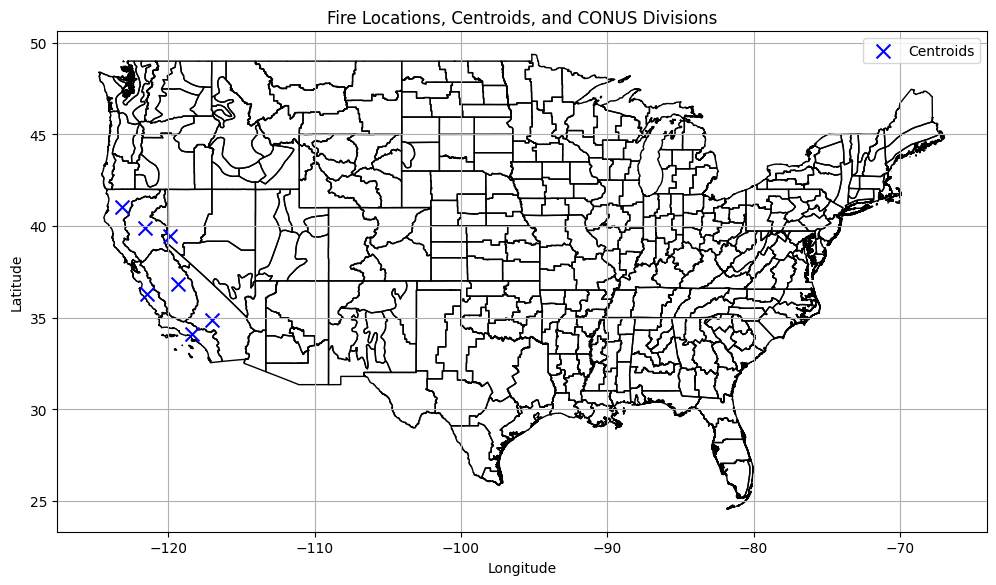

In [ ]:
# Plot weighted points in a map
conus_gdf = conus_divisions

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CONUS boundaries
conus_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="CONUS Boundaries")

# Extract latitude and longitude from the Point objects
weighted_centroid_series_x = weighted_centroid_series.apply(lambda point: point.x if point else None)
weighted_centroid_series_y = weighted_centroid_series.apply(lambda point: point.y if point else None)
# Plot centroids using extracted coordinates
ax.scatter(weighted_centroid_series_x, weighted_centroid_series_y, marker='x', color='blue', s=100, label='Centroids') #changed

# Labels and legend
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Fire Locations, Centroids, and CONUS Divisions")
plt.legend()
plt.grid(True)

# Show plot
plt.show()

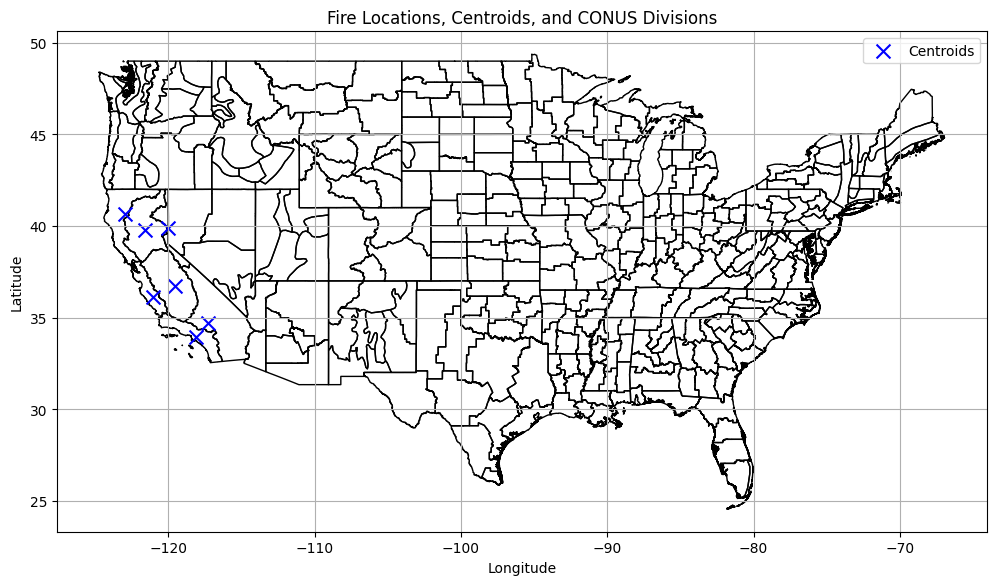

In [ ]:
# Plot unweighted points in a map

conus_gdf = conus_divisions
# Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot CONUS boundaries
conus_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="CONUS Boundaries")

# Extract latitude and longitude from the Point objects
centroid_series_x = centroid_series.apply(lambda point: point.x if point else None)
centroid_series_y = centroid_series.apply(lambda point: point.y if point else None)
# Plot centroids using extracted coordinates
ax.scatter(centroid_series_x, centroid_series_y, marker='x', color='blue', s=100, label='Centroids') #changed

# Labels and legend
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Fire Locations, Centroids, and CONUS Divisions")
plt.legend()
plt.grid(True)

# Show plot
plt.show()

### Moved forward by downloading geo located weather data from NASA POWER using the unweighted centroids calculated above. (Some of the weighted points were outside the state of california)

#### Example:
-BEGIN HEADER-
NASA/POWER Source Native Resolution Daily Data
Dates (month/day/year): 01/01/1984 through 04/01/2025 in LST
Location: latitude 40.9136 longitude -122.7412
elevation from MERRA-2: Average for 0.5 x 0.625 degree lat/lon region = 1063.01 meters
The value for missing source data that cannot be computed or is outside of the sources availability range: -999
parameter(s):
T2M MERRA-2 Temperature at 2 Meters (C)
T2M_RANGE MERRA-2 Temperature at 2 Meters Range (C)
T2M_MAX MERRA-2 Temperature at 2 Meters Maximum (C)
T2M_MIN MERRA-2 Temperature at 2 Meters Minimum (C)
QV2M MERRA-2 Specific Humidity at 2 Meters (g/kg)
RH2M MERRA-2 Relative Humidity at 2 Meters (%)
PRECTOTCORR MERRA-2 Precipitation Corrected (mm/day)
WS10M MERRA-2 Wind Speed at 10 Meters (m/s)
WS10M_MAX MERRA-2 Wind Speed at 10 Meters Maximum (m/s)
WS10M_MIN MERRA-2 Wind Speed at 10 Meters Minimum (m/s)
WS10M_RANGE MERRA-2 Wind Speed at 10 Meters Range (m/s)
WD10M MERRA-2 Wind Direction at 10 Meters (Degrees)
-END HEADER-



In [ ]:
# Read the merged fire data and set the 'date' column as index.
final_fire_data = merged_df

# Use glob to find all CONUS climate files. Adjust the path/pattern as necessary.
climate_files = glob.glob('/content/drive/MyDrive/DATASCI207/Final Project/data/CONUS_CLIMATE_*.csv')

for file in climate_files:

    # Read the climate file, skipping the header section
    with open(file, 'r') as f:
        lines = f.readlines()

    # Find the line number where actual data starts (after `-END HEADER-`)
    start_line = next(i for i, line in enumerate(lines) if line.strip() == "-END HEADER-") + 1

    # Read the CSV from the first line after `-END HEADER-`
    climate_df = pd.read_csv(file, skiprows=start_line)

    # Create a new date column from YEAR, MO, DY
    climate_df['date'] = pd.to_datetime(climate_df[['YEAR', 'MO', 'DY']].rename(columns={'DY': 'day', 'MO': 'month', 'YEAR': 'year'}))

    # Set date as the index
    climate_df.set_index('date', inplace=True)

    # Drop original YEAR, MO, DY columns
    climate_df.drop(columns=['YEAR', 'MO', 'DY'], inplace=True)

    # Extract the last 4 digits from the filename.
    # "CONUS_CLIMATE_0401.csv" extract "0401".
    base_name = os.path.basename(file)
    suffix = base_name.split('_')[-1].split('.')[0]

    # Rename all columns by appending the suffix.
    new_columns = {col: f"{col}_{suffix}" for col in climate_df.columns}
    climate_df.rename(columns=new_columns, inplace=True)

    # Merge the climate data into the fire_data dataframe on the date index.
    final_fire_data = final_fire_data.merge(climate_df, left_index=True, right_index=True, how='left')


In [ ]:
# Explore the dataset
display(final_fire_data)

,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR,INC_NUM,CAUSE,ACRES,longitude,latitude,county,conus_code,conus_name,DURATION,fire_occurrences,T2M_0404,T2M_RANGE_0404,T2M_MAX_0404,T2M_MIN_0404,QV2M_0404,RH2M_0404,PRECTOTCORR_0404,WS10M_0404,WS10M_MAX_0404,WS10M_MIN_0404,WS10M_RANGE_0404,WD10M_0404,T2M_0401,T2M_RANGE_0401,T2M_MAX_0401,T2M_MIN_0401,QV2M_0401,RH2M_0401,PRECTOTCORR_0401,WS10M_0401,WS10M_MAX_0401,WS10M_MIN_0401,WS10M_RANGE_0401,WD10M_0401,T2M_0403,T2M_RANGE_0403,T2M_MAX_0403,T2M_MIN_0403,QV2M_0403,RH2M_0403,PRECTOTCORR_0403,WS10M_0403,WS10M_MAX_0403,WS10M_MIN_0403,WS10M_RANGE_0403,WD10M_0403,T2M_0402,T2M_RANGE_0402,T2M_MAX_0402,T2M_MIN_0402,QV2M_0402,RH2M_0402,PRECTOTCORR_0402,WS10M_0402,WS10M_MAX_0402,WS10M_MIN_0402,WS10M_RANGE_0402,WD10M_0402,T2M_0405,T2M_RANGE_0405,T2M_MAX_0405,T2M_MIN_0405,QV2M_0405,RH2M_0405,PRECTOTCORR_0405,WS10M_0405,WS10M_MAX_0405,WS10M_MIN_0405,WS10M_RANGE_0405,WD10M_0405,T2M_0406,T2M_RANGE_0406,T2M_MAX_0406,T2M_MIN_0406,QV2M_0406,RH2M_0406,PRECTOTCORR_0406,WS10M_0406,WS10M_MAX_0406,WS10M_MIN_0406,WS10M_RANGE_0406,WD10M_0406,T2M_0407,T2M_RANGE_0407,T2M_MAX_0407,T2M_MIN_0407,QV2M_0407,RH2M_0407,PRECTOTCORR_0407,WS10M_0407,WS10M_MAX_0407,WS10M_MIN_0407,WS10M_RANGE_0407,WD10M_0407
1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700000,1,not_used,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0,7.51,11.94,15.51,3.57,5.61,84.72,0.01,2.13,2.44,1.75,0.69,23.2,2.59,8.81,8.46,-0.35,4.12,79.57,0.00,2.06,2.59,1.22,1.37,12.8,-1.97,6.05,2.10,-3.95,3.34,89.63,0.02,1.25,2.57,0.21,2.36,75.8,8.71,11.44,16.42,4.98,6.00,86.44,0.05,3.34,4.81,1.36,3.45,17.8,6.11,12.50,14.18,1.68,4.12,63.23,0.07,3.18,4.67,0.27,4.40,60.3,13.77,7.39,18.51,11.12,5.32,54.97,0.01,8.67,12.00,6.45,5.55,30.6,6.13,10.36,12.60,2.24,2.85,46.50,0.00,5.88,9.39,3.55,5.84,31.5
1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145000,2,not_used,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0,8.94,13.62,16.85,3.23,5.18,70.86,0.00,2.10,3.06,1.28,1.78,85.2,5.13,8.81,10.55,1.74,4.61,73.98,0.00,2.48,2.88,1.69,1.19,3.9,-1.53,8.55,3.31,-5.24,3.01,78.85,0.02,0.97,1.53,0.30,1.23,55.3,8.63,12.78,16.94,4.16,5.97,86.49,0.01,3.10,4.69,0.74,3.95,30.0,7.19,11.74,14.90,3.16,4.19,58.96,0.18,3.47,5.60,0.68,4.92,62.5,12.30,7.91,17.38,9.47,4.20,48.15,0.00,9.19,11.54,6.76,4.78,33.1,4.17,12.79,11.76,-1.03,1.97,37.85,0.00,6.41,10.54,4.62,5.92,39.7
1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220000,3,not_used,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0,11.91,11.49,18.85,7.36,5.06,55.88,0.01,1.25,1.91,0.59,1.32,97.6,7.93,9.69,14.23,4.54,6.35,84.50,0.03,2.36,2.79,1.55,1.24,1.3,0.39,9.53,6.26,-3.27,2.80,63.38,0.09,0.79,1.71,0.17,1.54,36.5,10.20,14.42,18.78,4.36,7.51,93.91,0.67,3.38,4.20,2.22,1.98,18.2,8.81,13.03,16.50,3.47,4.73,59.32,0.06,2.61,4.48,0.51,3.97,65.2,13.03,9.39,19.10,9.71,4.75,51.24,0.00,7.02,8.75,4.37,4.38,33.7,5.44,14.29,14.12,-0.17,2.27,39.57,0.00,4.58,7.30,2.83,4.47,43.6
1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090000,4,not_used,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0,13.28,11.88,20.37,8.49,5.07,51.25,0.00,1.62,2.21,0.79,1.42,122.9,6.79,10.01,13.15,3.14,6.02,87.89,0.00,2.05,2.72,0.95,1.77,17.0,1.26,8.18,6.61,-1.57,3.64,74.57,0.14,1.36,2.29,0.37,1.92,52.6,11.97,12.95,20.61,7.66,7.35,84.68,0.06,2.91,3.77,1.02,2.75,25.9,11.05,11.35,18.42,7.07,6.28,69.22,0.04,3.06,4.53,0.42,4.11,65.6,14.69,9.49,20.80,11.31,5.63,54.45,0.00,6.03,7.83,2.08,5.75,37.0,7.57,14.11,16.15,2.04,3.48,50.91,0.00,4.66,7.89,3.09,4.80,44.0
1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100000,5,not_used,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0,12.48,12.86,20.22,7.36,5.79,62.41,0.01,1.43,2.77,0.20,2.57,86.7,6.18,10.40,13.18,2.78,5.69,85.38,0.16

### At this point the merged dataframe can be downloaded

In [ ]:
final_fire_data.reset_index(inplace=True)
final_fire_data.rename(columns={'index': 'DATE'}, inplace=True)

# Convert the numeric column to string
final_fire_data.drop(columns=['INC_NUM'], inplace=True)
final_fire_data.to_csv('merged_fire_data_9a.csv', index=False)
files.download('merged_fire_data_9a.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Explore the dataset
display(final_fire_data)

,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR,CAUSE,ACRES,longitude,latitude,county,conus_code,conus_name,DURATION,fire_occurrences,geometry,T2M_0404,T2M_RANGE_0404,T2M_MAX_0404,T2M_MIN_0404,QV2M_0404,RH2M_0404,PRECTOTCORR_0404,WS10M_0404,WS10M_MAX_0404,WS10M_MIN_0404,WS10M_RANGE_0404,WD10M_0404,T2M_0401,T2M_RANGE_0401,T2M_MAX_0401,T2M_MIN_0401,QV2M_0401,RH2M_0401,PRECTOTCORR_0401,WS10M_0401,WS10M_MAX_0401,WS10M_MIN_0401,WS10M_RANGE_0401,WD10M_0401,T2M_0403,T2M_RANGE_0403,T2M_MAX_0403,T2M_MIN_0403,QV2M_0403,RH2M_0403,PRECTOTCORR_0403,WS10M_0403,WS10M_MAX_0403,WS10M_MIN_0403,WS10M_RANGE_0403,WD10M_0403,T2M_0402,T2M_RANGE_0402,T2M_MAX_0402,T2M_MIN_0402,QV2M_0402,RH2M_0402,PRECTOTCORR_0402,WS10M_0402,WS10M_MAX_0402,WS10M_MIN_0402,WS10M_RANGE_0402,WD10M_0402,T2M_0405,T2M_RANGE_0405,T2M_MAX_0405,T2M_MIN_0405,QV2M_0405,RH2M_0405,PRECTOTCORR_0405,WS10M_0405,WS10M_MAX_0405,WS10M_MIN_0405,WS10M_RANGE_0405,WD10M_0405,T2M_0406,T2M_RANGE_0406,T2M_MAX_0406,T2M_MIN_0406,QV2M_0406,RH2M_0406,PRECTOTCORR_0406,WS10M_0406,WS10M_MAX_0406,WS10M_MIN_0406,WS10M_RANGE_0406,WD10M_0406,T2M_0407,T2M_RANGE_0407,T2M_MAX_0407,T2M_MIN_0407,QV2M_0407,RH2M_0407,PRECTOTCORR_0407,WS10M_0407,WS10M_MAX_0407,WS10M_MIN_0407,WS10M_RANGE_0407,WD10M_0407
0,1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700000,1,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0,POINT (0 0),7.51,11.94,15.51,3.57,5.61,84.72,0.01,2.13,2.44,1.75,0.69,23.2,2.59,8.81,8.46,-0.35,4.12,79.57,0.00,2.06,2.59,1.22,1.37,12.8,-1.97,6.05,2.10,-3.95,3.34,89.63,0.02,1.25,2.57,0.21,2.36,75.8,8.71,11.44,16.42,4.98,6.00,86.44,0.05,3.34,4.81,1.36,3.45,17.8,6.11,12.50,14.18,1.68,4.12,63.23,0.07,3.18,4.67,0.27,4.40,60.3,13.77,7.39,18.51,11.12,5.32,54.97,0.01,8.67,12.00,6.45,5.55,30.6,6.13,10.36,12.60,2.24,2.85,46.50,0.00,5.88,9.39,3.55,5.84,31.5
1,1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145000,2,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0,POINT (0 0),8.94,13.62,16.85,3.23,5.18,70.86,0.00,2.10,3.06,1.28,1.78,85.2,5.13,8.81,10.55,1.74,4.61,73.98,0.00,2.48,2.88,1.69,1.19,3.9,-1.53,8.55,3.31,-5.24,3.01,78.85,0.02,0.97,1.53,0.30,1.23,55.3,8.63,12.78,16.94,4.16,5.97,86.49,0.01,3.10,4.69,0.74,3.95,30.0,7.19,11.74,14.90,3.16,4.19,58.96,0.18,3.47,5.60,0.68,4.92,62.5,12.30,7.91,17.38,9.47,4.20,48.15,0.00,9.19,11.54,6.76,4.78,33.1,4.17,12.79,11.76,-1.03,1.97,37.85,0.00,6.41,10.54,4.62,5.92,39.7
2,1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220000,3,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0,POINT (0 0),11.91,11.49,18.85,7.36,5.06,55.88,0.01,1.25,1.91,0.59,1.32,97.6,7.93,9.69,14.23,4.54,6.35,84.50,0.03,2.36,2.79,1.55,1.24,1.3,0.39,9.53,6.26,-3.27,2.80,63.38,0.09,0.79,1.71,0.17,1.54,36.5,10.20,14.42,18.78,4.36,7.51,93.91,0.67,3.38,4.20,2.22,1.98,18.2,8.81,13.03,16.50,3.47,4.73,59.32,0.06,2.61,4.48,0.51,3.97,65.2,13.03,9.39,19.10,9.71,4.75,51.24,0.00,7.02,8.75,4.37,4.38,33.7,5.44,14.29,14.12,-0.17,2.27,39.57,0.00,4.58,7.30,2.83,4.47,43.6
3,1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090000,4,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0,POINT (0 0),13.28,11.88,20.37,8.49,5.07,51.25,0.00,1.62,2.21,0.79,1.42,122.9,6.79,10.01,13.15,3.14,6.02,87.89,0.00,2.05,2.72,0.95,1.77,17.0,1.26,8.18,6.61,-1.57,3.64,74.57,0.14,1.36,2.29,0.37,1.92,52.6,11.97,12.95,20.61,7.66,7.35,84.68,0.06,2.91,3.77,1.02,2.75,25.9,11.05,11.35,18.42,7.07,6.28,69.22,0.04,3.06,4.53,0.42,4.11,65.6,14.69,9.49,20.80,11.31,5.63,54.45,0.00,6.03,7.83,2.08,5.75,37.0,7.57,14.11,16.15,2.04,3.48,50.91,0.00,4.66,7.89,3.09,4.80,44.0
4,1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100000,5,999.0,0.000000,0.000000,0.000000,not_used,not_used,not_used,0.0,0.0,POINT (0 0),12.48,12.86,20.22,7.36,5.79,62.41,0.01,1.43,2.77,0.20,2.57,86.7,6.18,1

### On a last experiment the rows with a fire started we left only the affected climate division weather data, setting the rest of the climate divisions to 0

In [ ]:
columns = [
    'T2M_0404', 'T2M_RANGE_0404', 'T2M_MAX_0404', 'T2M_MIN_0404', 'QV2M_0404', 'RH2M_0404', 'PRECTOTCORR_0404',
    'WS10M_0404', 'WS10M_MAX_0404', 'WS10M_MIN_0404', 'WS10M_RANGE_0404', 'WD10M_0404',
    'T2M_0401', 'T2M_RANGE_0401', 'T2M_MAX_0401', 'T2M_MIN_0401', 'QV2M_0401', 'RH2M_0401', 'PRECTOTCORR_0401',
    'WS10M_0401', 'WS10M_MAX_0401', 'WS10M_MIN_0401', 'WS10M_RANGE_0401', 'WD10M_0401',
    'T2M_0403', 'T2M_RANGE_0403', 'T2M_MAX_0403', 'T2M_MIN_0403', 'QV2M_0403', 'RH2M_0403', 'PRECTOTCORR_0403',
    'WS10M_0403', 'WS10M_MAX_0403', 'WS10M_MIN_0403', 'WS10M_RANGE_0403', 'WD10M_0403',
    'T2M_0402', 'T2M_RANGE_0402', 'T2M_MAX_0402', 'T2M_MIN_0402', 'QV2M_0402', 'RH2M_0402', 'PRECTOTCORR_0402',
    'WS10M_0402', 'WS10M_MAX_0402', 'WS10M_MIN_0402', 'WS10M_RANGE_0402', 'WD10M_0402',
    'T2M_0405', 'T2M_RANGE_0405', 'T2M_MAX_0405', 'T2M_MIN_0405', 'QV2M_0405', 'RH2M_0405', 'PRECTOTCORR_0405',
    'WS10M_0405', 'WS10M_MAX_0405', 'WS10M_MIN_0405', 'WS10M_RANGE_0405', 'WD10M_0405',
    'T2M_0406', 'T2M_RANGE_0406', 'T2M_MAX_0406', 'T2M_MIN_0406', 'QV2M_0406', 'RH2M_0406', 'PRECTOTCORR_0406',
    'WS10M_0406', 'WS10M_MAX_0406', 'WS10M_MIN_0406', 'WS10M_RANGE_0406', 'WD10M_0406',
    'T2M_0407', 'T2M_RANGE_0407', 'T2M_MAX_0407', 'T2M_MIN_0407', 'QV2M_0407', 'RH2M_0407', 'PRECTOTCORR_0407',
    'WS10M_0407', 'WS10M_MAX_0407', 'WS10M_MIN_0407', 'WS10M_RANGE_0407', 'WD10M_0407'
]

# Get all data columns (excluding 'conus_code')
data_cols = [col for col in final_fire_data.columns if col != 'conus_code']

def filter_by_code(row):
    # Convert conus_code to a string, strip whitespace, and add leading zeros if needed
    raw_code = str(row['conus_code']).strip()
    # If the code is not 'not_used', ensure it is 4 digits long
    code = raw_code if raw_code == 'not_used' else raw_code.zfill(4)
    code = str(code)
    print(f"\nProcessing row with conus_code: '{code}' (raw: '{raw_code}')")

    # If code is 'not_used', leave the row unchanged.
    if code == 'not_used':
        print(" -> conus_code is 'not_used', keeping row unchanged.")
        return row[data_cols]

    new_row = {}
    for col in data_cols:
        # Check if the column name ends with a 4-digit suffix (assumes suffix format is _XXXX)
        if '_' in col and col[-4:].isdigit():
            suffix = col[-4:]
            match = (suffix == code)
            print(f"   Column: {col} | Suffix: {suffix} | Code matches? {match}")
            new_row[col] = row[col] if match else 0
        else:
            # For columns without a recognized suffix, keep the original value.
            new_row[col] = row[col]
            print(f"   Column: {col} has no 4-digit suffix. Keeping original value.")
    return pd.Series(new_row)

# Apply the transformation row-wise
filtered_data = final_fire_data.apply(filter_by_code, axis=1)

# Reconstruct the DataFrame with the 'conus_code' column.
filtered_final_fire_data = pd.concat(
    [final_fire_data[['conus_code']].reset_index(drop=True),
     filtered_data.reset_index(drop=True)],
    axis=1
)

Se han truncado las últimas 5000 líneas del flujo de salida.
   Column: PRECTOTCORR_0402 | Suffix: 0402 | Code matches? False
   Column: WS10M_0402 | Suffix: 0402 | Code matches? False
   Column: WS10M_MAX_0402 | Suffix: 0402 | Code matches? False
   Column: WS10M_MIN_0402 | Suffix: 0402 | Code matches? False
   Column: WS10M_RANGE_0402 | Suffix: 0402 | Code matches? False
   Column: WD10M_0402 | Suffix: 0402 | Code matches? False
   Column: T2M_0405 | Suffix: 0405 | Code matches? False
   Column: T2M_RANGE_0405 | Suffix: 0405 | Code matches? False
   Column: T2M_MAX_0405 | Suffix: 0405 | Code matches? False
   Column: T2M_MIN_0405 | Suffix: 0405 | Code matches? False
   Column: QV2M_0405 | Suffix: 0405 | Code matches? False
   Column: RH2M_0405 | Suffix: 0405 | Code matches? False
   Column: PRECTOTCORR_0405 | Suffix: 0405 | Code matches? False
   Column: WS10M_0405 | Suffix: 0405 | Code matches? False
   Column: WS10M_MAX_0405 | Suffix: 0405 | Code matches? False
   Column: WS10M_MIN

In [ ]:
# Explore the resulting datase
print("Filtered final_fire_data:")
display(filtered_final_fire_data)

Filtered final_fire_data:


,conus_code,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR,CAUSE,ACRES,longitude,latitude,county,conus_name,DURATION,fire_occurrences,geometry,T2M_0404,T2M_RANGE_0404,T2M_MAX_0404,T2M_MIN_0404,QV2M_0404,RH2M_0404,PRECTOTCORR_0404,WS10M_0404,WS10M_MAX_0404,WS10M_MIN_0404,WS10M_RANGE_0404,WD10M_0404,T2M_0401,T2M_RANGE_0401,T2M_MAX_0401,T2M_MIN_0401,QV2M_0401,RH2M_0401,PRECTOTCORR_0401,WS10M_0401,WS10M_MAX_0401,WS10M_MIN_0401,WS10M_RANGE_0401,WD10M_0401,T2M_0403,T2M_RANGE_0403,T2M_MAX_0403,T2M_MIN_0403,QV2M_0403,RH2M_0403,PRECTOTCORR_0403,WS10M_0403,WS10M_MAX_0403,WS10M_MIN_0403,WS10M_RANGE_0403,WD10M_0403,T2M_0402,T2M_RANGE_0402,T2M_MAX_0402,T2M_MIN_0402,QV2M_0402,RH2M_0402,PRECTOTCORR_0402,WS10M_0402,WS10M_MAX_0402,WS10M_MIN_0402,WS10M_RANGE_0402,WD10M_0402,T2M_0405,T2M_RANGE_0405,T2M_MAX_0405,T2M_MIN_0405,QV2M_0405,RH2M_0405,PRECTOTCORR_0405,WS10M_0405,WS10M_MAX_0405,WS10M_MIN_0405,WS10M_RANGE_0405,WD10M_0405,T2M_0406,T2M_RANGE_0406,T2M_MAX_0406,T2M_MIN_0406,QV2M_0406,RH2M_0406,PRECTOTCORR_0406,WS10M_0406,WS10M_MAX_0406,WS10M_MIN_0406,WS10M_RANGE_0406,WD10M_0406,T2M_0407,T2M_RANGE_0407,T2M_MAX_0407,T2M_MIN_0407,QV2M_0407,RH2M_0407,PRECTOTCORR_0407,WS10M_0407,WS10M_MAX_0407,WS10M_MIN_0407,WS10M_RANGE_0407,WD10M_0407
0,not_used,1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700000,1,999.0,0.000000,0.000000,0.000000,not_used,not_used,0.0,0.0,POINT (0 0),7.51,11.94,15.51,3.57,5.61,84.72,0.01,2.13,2.44,1.75,0.69,23.2,2.59,8.81,8.46,-0.35,4.12,79.57,0.00,2.06,2.59,1.22,1.37,12.8,-1.97,6.05,2.10,-3.95,3.34,89.63,0.02,1.25,2.57,0.21,2.36,75.8,8.71,11.44,16.42,4.98,6.00,86.44,0.05,3.34,4.81,1.36,3.45,17.8,6.11,12.50,14.18,1.68,4.12,63.23,0.07,3.18,4.67,0.27,4.40,60.3,13.77,7.39,18.51,11.12,5.32,54.97,0.01,8.67,12.00,6.45,5.55,30.6,6.13,10.36,12.60,2.24,2.85,46.50,0.00,5.88,9.39,3.55,5.84,31.5
1,not_used,1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145000,2,999.0,0.000000,0.000000,0.000000,not_used,not_used,0.0,0.0,POINT (0 0),8.94,13.62,16.85,3.23,5.18,70.86,0.00,2.10,3.06,1.28,1.78,85.2,5.13,8.81,10.55,1.74,4.61,73.98,0.00,2.48,2.88,1.69,1.19,3.9,-1.53,8.55,3.31,-5.24,3.01,78.85,0.02,0.97,1.53,0.30,1.23,55.3,8.63,12.78,16.94,4.16,5.97,86.49,0.01,3.10,4.69,0.74,3.95,30.0,7.19,11.74,14.90,3.16,4.19,58.96,0.18,3.47,5.60,0.68,4.92,62.5,12.30,7.91,17.38,9.47,4.20,48.15,0.00,9.19,11.54,6.76,4.78,33.1,4.17,12.79,11.76,-1.03,1.97,37.85,0.00,6.41,10.54,4.62,5.92,39.7
2,not_used,1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220000,3,999.0,0.000000,0.000000,0.000000,not_used,not_used,0.0,0.0,POINT (0 0),11.91,11.49,18.85,7.36,5.06,55.88,0.01,1.25,1.91,0.59,1.32,97.6,7.93,9.69,14.23,4.54,6.35,84.50,0.03,2.36,2.79,1.55,1.24,1.3,0.39,9.53,6.26,-3.27,2.80,63.38,0.09,0.79,1.71,0.17,1.54,36.5,10.20,14.42,18.78,4.36,7.51,93.91,0.67,3.38,4.20,2.22,1.98,18.2,8.81,13.03,16.50,3.47,4.73,59.32,0.06,2.61,4.48,0.51,3.97,65.2,13.03,9.39,19.10,9.71,4.75,51.24,0.00,7.02,8.75,4.37,4.38,33.7,5.44,14.29,14.12,-0.17,2.27,39.57,0.00,4.58,7.30,2.83,4.47,43.6
3,not_used,1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090000,4,999.0,0.000000,0.000000,0.000000,not_used,not_used,0.0,0.0,POINT (0 0),13.28,11.88,20.37,8.49,5.07,51.25,0.00,1.62,2.21,0.79,1.42,122.9,6.79,10.01,13.15,3.14,6.02,87.89,0.00,2.05,2.72,0.95,1.77,17.0,1.26,8.18,6.61,-1.57,3.64,74.57,0.14,1.36,2.29,0.37,1.92,52.6,11.97,12.95,20.61,7.66,7.35,84.68,0.06,2.91,3.77,1.02,2.75,25.9,11.05,11.35,18.42,7.07,6.28,69.22,0.04,3.06,4.53,0.42,4.11,65.6,14.69,9.49,20.80,11.31,5.63,54.45,0.00,6.03,7.83,2.08,5.75,37.0,7.57,14.11,16.15,2.04,3.48,50.91,0.00,4.66,7.89,3.09,4.80,44.0
4,not_used,1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100000,5,999.0,0.000000,0.000000,0.000000,not_used,not_used,0.0,0.0,POINT (0 0),12.48,12.86,20.22,7.36,5.79,62.41,0.01,1.43,2.77,0.20,2.57,86.7,6.18,1

In [ ]:
# Recover index as date
filtered_final_fire_data.reset_index(inplace=True)
filtered_final_fire_data.rename(columns={'index': 'DATE'}, inplace=True)

# Download the merged file
filtered_final_fire_data.to_csv('merged_fire_data_10.csv', index=False)
files.download('merged_fire_data_10.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>